In [57]:
import numpy as np
import pandas as pd
import seaborn as sns 

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression



import warnings
warnings.filterwarnings("ignore")

In [58]:
titanic_data= pd.read_csv('Titanic.csv')
titanic_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [59]:
titanic_data.shape

(891, 12)

In [60]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [61]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [62]:
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [63]:
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [188]:
titanic_data=titanic_data.drop(columns=['Cabin'],axis=1,inplace=True)
titanic_data.head()
#droping cabin column as it has a lot of missing values


KeyError: "['Cabin'] not found in axis"

In [65]:
#filling in the missing vlues in the Age collumn using Linear Regerssion
feature=['Pclass','SibSp','Parch','Fare','Survived']
age_known=titanic_data[titanic_data['Age'].notnull()]
age_unknown=titanic_data[titanic_data['Age'].isnull()]

X_train=age_known[feature]
y_train=age_known['Age']

X_predict=age_unknown[feature]

reg=LinearRegression()
reg.fit(X_train,y_train)

predicted_age=reg.predict(X_predict)
titanic_data.loc[titanic_data['Age'].isnull(),'Age']=predicted_age

In [66]:
#checking for missing values in embarkment column
print(titanic_data['Embarked'].mode())
print(titanic_data['Embarked'].mode()[0])


0    S
Name: Embarked, dtype: object
S


In [67]:
#filling in the missing vlues in the Embarkment collumn using mode
print(titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0], inplace=True))

None


In [68]:
titanic_data.isnull().sum()
#data is clean now, no null values

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [138]:
age_bins = [-np.inf, 15, 31, 56, 81, np.inf]
age_labels = ['G1', 'G2', 'G3', 'G4', 'G5']
titanic_data['Age_Group'] = pd.cut(titanic_data['Age'], bins=age_bins, labels=age_labels, right=False)
titanic_data[['Age', 'Age_Group']].head()
#classifining age into there respective groups


,Age,Age_Group
0,22.0,G2
1,38.0,G3
2,26.0,G2
3,35.0,G3
4,35.0,G3


In [139]:
titanic_data['Age_Group'].value_counts().sort_index()

Age_Group
G1     87
G2    464
G3    301
G4     39
G5      0
Name: count, dtype: int64

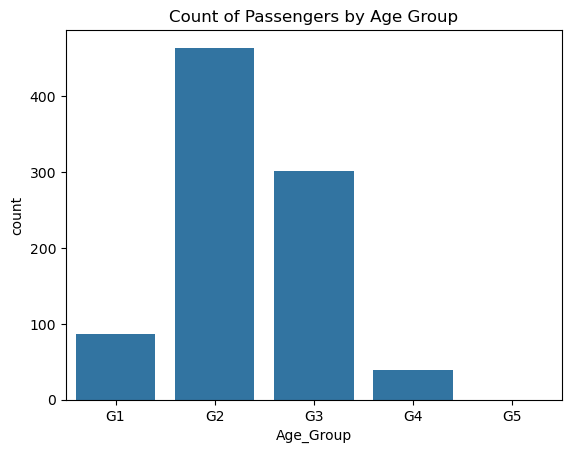

In [189]:
sns.countplot(x='Age_Group',data=titanic_data)
plt.title("Count of Passengers by Age Group")
plt.show()

In [140]:
titanic_data['Age_Group']=pd.cut(titanic_data['Age'],bins=age_bins,labels=age_labels,right=False)
#adding a new column names as Age_Group to the titanic dataset 

In [141]:
titanic_data.to_csv("Titanic_With_Age_Groups.csv",index=False)
#saving the new csv file with the classified age groups

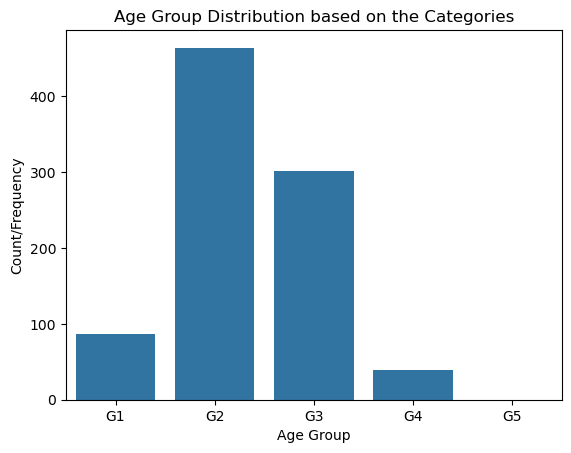

In [142]:
sns.countplot(x='Age_Group', data=titanic_data)
plt.title("Age Group Distribution based on the Categories")
plt.xlabel("Age Group")
plt.ylabel("Count/Frequency")
plt.show()

In [143]:
# titanic_data['Sex']=titanic_data['Sex'].map({'male':0,'female':1})

In [144]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_Group,Family_Size,IsAlone,Title,FareGroup,FareBand,Fare_Per_Person,Cluster
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,G2,2,False,Mr,Low,0,3.62500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1,G3,2,False,Mrs,Very High,3,35.64165,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0,G2,1,1,Miss,Medium,1,7.92500,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0,G3,2,False,Mrs,Very High,3,26.55000,4
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0,G3,1,1,Mr,Medium,1,8.05000,0


In [145]:
titanic_data['Fare'].isnull().sum()

0

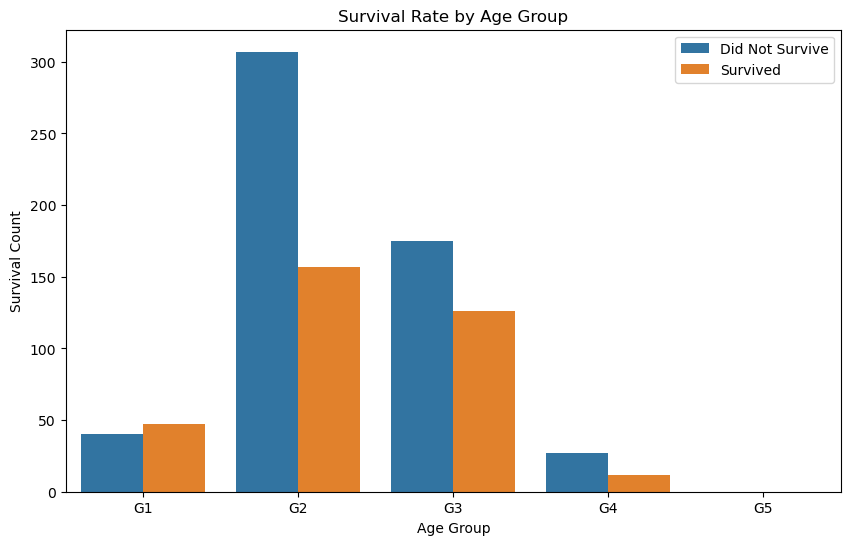

In [146]:
#Age Group vs Survival Rate
plt.figure(figsize=(10,6))
sns.countplot(x='Age_Group',hue='Survived',data=titanic_data)
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Count")
plt.legend(labels=["Did Not Survive","Survived"])
plt.show()

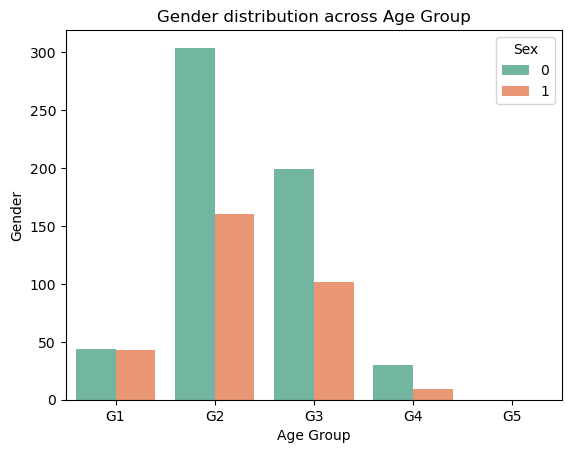

In [147]:
#Age Group vs Gender
sns.countplot(x='Age_Group',hue='Sex',data=titanic_data,palette="Set2")
plt.title("Gender distribution across Age Group")
plt.xlabel("Age Group")
plt.ylabel("Gender")
plt.show()



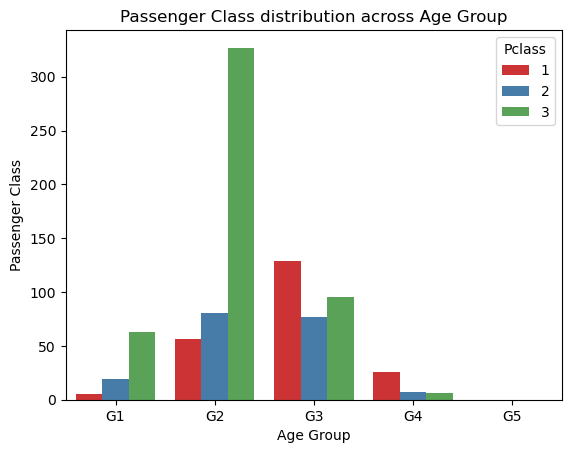

In [148]:
#Age Group vs PClass
sns.countplot(x='Age_Group',hue='Pclass',data=titanic_data,palette="Set1")
plt.title("Passenger Class distribution across Age Group")
plt.xlabel("Age Group")
plt.ylabel("Passenger Class")
plt.show()


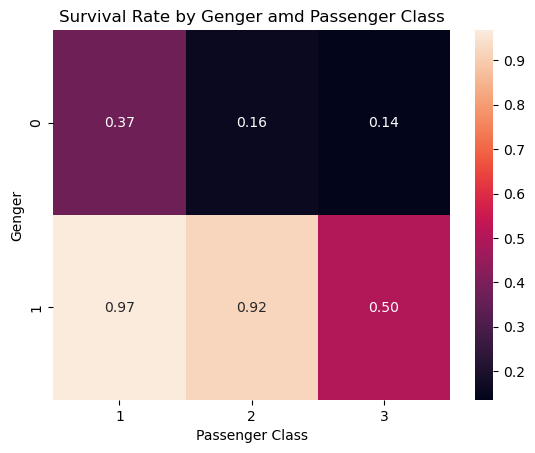

In [149]:
pivot=pd.pivot_table(titanic_data,values='Survived',index='Sex',columns='Pclass',aggfunc='mean')
sns.heatmap(pivot,annot=True,fmt=".2f")
plt.title("Survival Rate by Genger amd Passenger Class")
plt.ylabel("Genger")
plt.xlabel("Passenger Class")
plt.show()


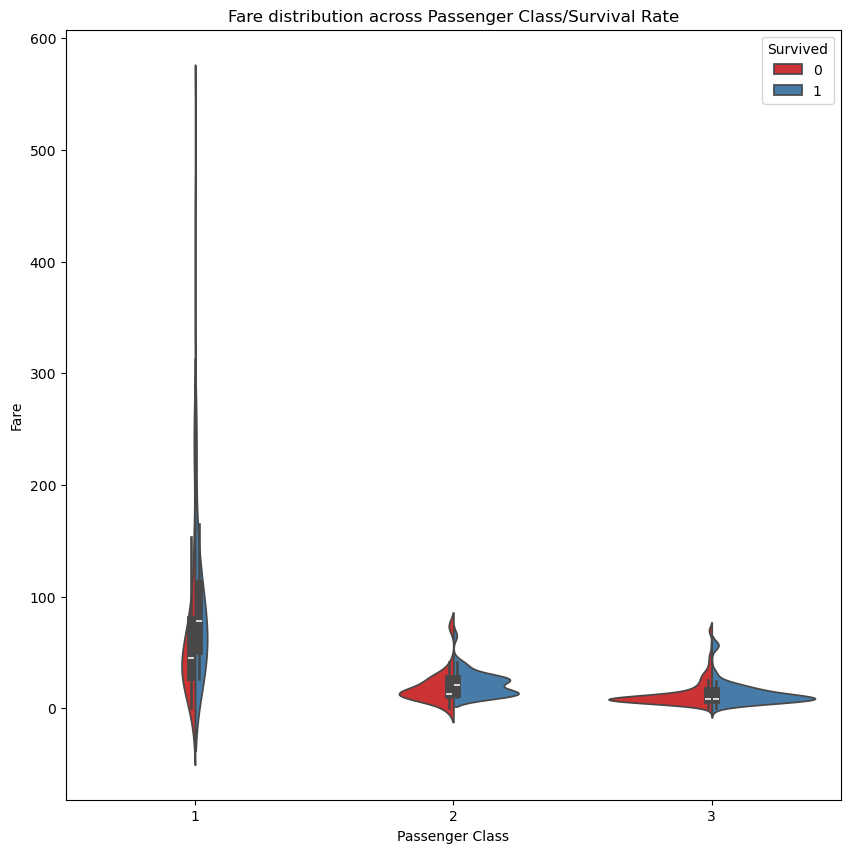

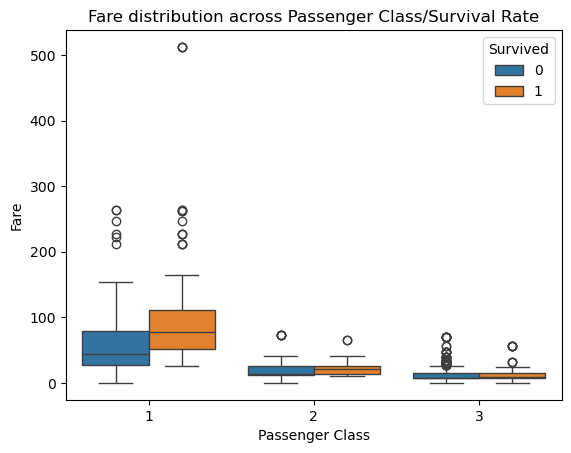

In [150]:
#Fare vs PClass
plt.figure(figsize=(10,10))
sns.violinplot(x='Pclass',y='Fare',hue="Survived",data=titanic_data,split=True,palette="Set1")
plt.title("Fare distribution across Passenger Class/Survival Rate")
plt.ylabel("Fare")
plt.xlabel("Passenger Class")
plt.show()


sns.boxplot(x='Pclass',y='Fare',hue="Survived",data=titanic_data)
plt.title("Fare distribution across Passenger Class/Survival Rate")
plt.ylabel("Fare")
plt.xlabel("Passenger Class")
plt.show()


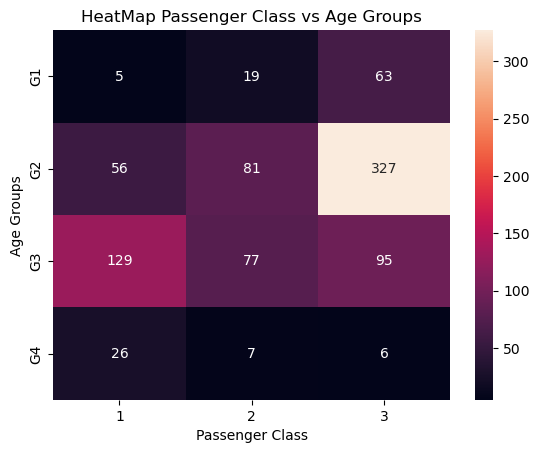

In [ ]:
#heat map for Fare vs PClass/Survival
ctab=pd.pivot_table(titanic_data['Age_Group'],titanic_data['Pclass'])
sns.heatmap(ctab,annot=True,fmt='d')
plt.title("HeatMap Passenger Class vs Age Groups")
plt.ylabel("Age Groups")
plt.xlabel("Passenger Class")
plt.show()


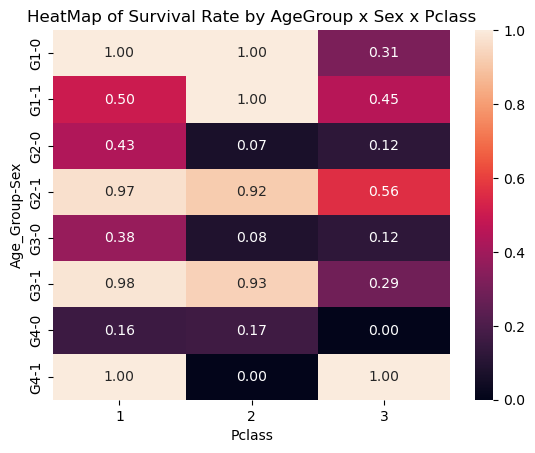

In [152]:
pv=pd.pivot_table(titanic_data,values='Survived',index=['Age_Group','Sex'],columns='Pclass',aggfunc='mean')
sns.heatmap(pv,annot=True,fmt='.2f')
plt.title("HeatMap of Survival Rate by AgeGroup x Sex x Pclass")
plt.show()

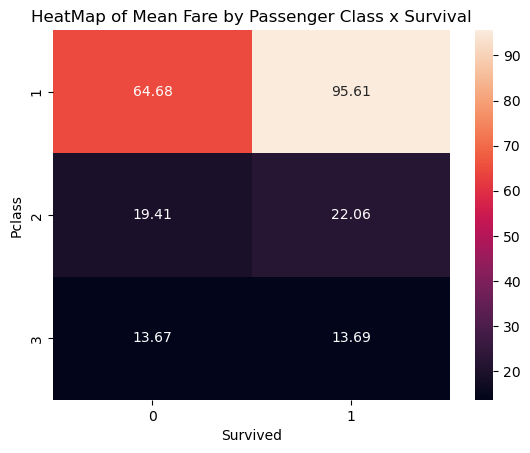

In [181]:
fare_pv=pd.pivot_table(titanic_data,values='Fare',index='Pclass',columns='Survived',aggfunc='mean')
sns.heatmap(fare_pv,annot=True,fmt='.2f')
plt.title("HeatMap of Mean Fare by Passenger Class x Survival")
plt.show()

In [153]:
titanic_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   PassengerId      891 non-null    int64   
 1   Survived         891 non-null    int64   
 2   Pclass           891 non-null    int64   
 3   Name             891 non-null    object  
 4   Sex              891 non-null    int64   
 5   Age              891 non-null    float64 
 6   SibSp            891 non-null    int64   
 7   Parch            891 non-null    int64   
 8   Ticket           891 non-null    object  
 9   Fare             891 non-null    float64 
 10  Embarked         891 non-null    int64   
 11  Age_Group        891 non-null    category
 12  Family_Size      891 non-null    int64   
 13  IsAlone          891 non-null    object  
 14  Title            891 non-null    object  
 15  FareGroup        891 non-null    category
 16  FareBand         891 non-null    category
 1

In [154]:
titanic_data["Sex"].value_counts()

Sex
0    577
1    314
Name: count, dtype: int64

In [155]:
titanic_data["Embarked"].value_counts()

Embarked
0    646
1    168
2     77
Name: count, dtype: int64

In [156]:
titanic_data.replace({'Sex':{'male':0, 'female':1}, 'Embarked':{'S':0, 'C':1, 'Q':2}}, inplace=True)

In [157]:
titanic_data['Family_Size']=titanic_data['SibSp']+titanic_data['Parch']+1
titanic_data['IsAlone']=(titanic_data['Family_Size']==1)


In [158]:
titanic_data.loc[titanic_data['Family_Size']==1,'IsAlone']=1

In [159]:
titanic_data['Title']=titanic_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False).str.strip()

title_count=titanic_data['Title'].value_counts()
rare_t=title_count[title_count<10].index
titanic_data['Title']=titanic_data['Title'].replace(rare_t,"Rare")
titanic_data['Title']=titanic_data['Title'].replace(['Mlle', 'Ms'], 'Miss')
titanic_data['Title']=titanic_data['Title'].replace('Mme', 'Mrs')

In [160]:
titanic_data['Fare'].fillna(titanic_data['Fare'].mean(), inplace=True)
titanic_data['FareGroup']= pd.qcut(titanic_data['Fare'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

In [161]:
titanic_data['FareBand']= pd.qcut(titanic_data['Fare'], q=4, labels=[0,1,2,3])

In [162]:
titanic_data['Fare_Per_Person']=titanic_data['Fare']/titanic_data['Family_Size']

In [163]:
from sklearn.preprocessing import LabelEncoder
features=['Pclass','Sex','Fare','Embarked','Family_Size','SibSp','Parch']
cat_features=['Sex','Embarked']
# X = titanic_data[features]
# Y = LabelEncoder().fit_transform(titanic_data["Age_Group"])
# x=pd.get_dummies(X,drop_first=True)
# #training and splitting the data
# X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [165]:

from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

pipe=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())
])
cat_pipe=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),('ohe',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

cat_pipe=ColumnTransformer(transformers=[ ('num',pipe,features),('cat',cat_pipe,cat_features)],remainder='drop')

X=titanic_data[features+cat_features]
Y=titanic_data['Age_Group']

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [166]:
print(X.shape, X_train.shape, X_test.shape)

(891, 9) (712, 9) (179, 9)


In [167]:
print(Y.shape, Y_train.shape, Y_test.shape)

(891,) (712,) (179,)


In [168]:
print(X_train.isnull().sum())

Pclass         0
Sex            0
Fare           0
Embarked       0
Family_Size    0
SibSp          0
Parch          0
Sex            0
Embarked       0
dtype: int64


In [169]:
print(Y_train.isnull().sum())
print(Y_test.isnull().sum())

0
0


LogisticRegression ==> Accuracy: 59.78%
              precision    recall  f1-score   support

          G1       0.27      0.23      0.25        13
          G2       0.68      0.76      0.72        93
          G3       0.52      0.53      0.52        62
          G4       0.00      0.00      0.00        11

    accuracy                           0.60       179
   macro avg       0.37      0.38      0.37       179
weighted avg       0.55      0.60      0.57       179

RandomForest ==> Accuracy: 60.89%
              precision    recall  f1-score   support

          G1       0.44      0.31      0.36        13
          G2       0.67      0.75      0.71        93
          G3       0.52      0.53      0.53        62
          G4       1.00      0.18      0.31        11

    accuracy                           0.61       179
   macro avg       0.66      0.44      0.48       179
weighted avg       0.62      0.61      0.60       179

KNeighbors ==> Accuracy: 58.10%
              precision 

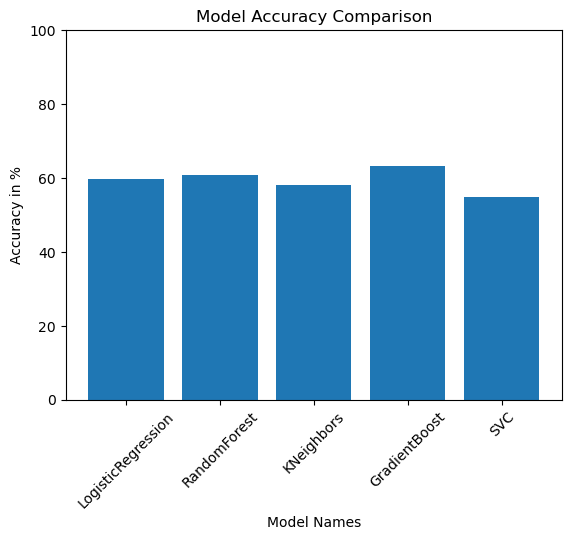

In [191]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report

models={ 'LogisticRegression':LogisticRegression(max_iter=200,multi_class='multinomial'),
         'RandomForest':RandomForestClassifier(n_estimators=200,random_state=42),
         'KNeighbors':KNeighborsClassifier(n_neighbors=5),
         'GradientBoost':GradientBoostingClassifier(random_state=42),
         'SVC':SVC(kernel='rbf',probability=True,random_state=42)
         }
result={}
def plot_fit(name,model):
    clf=Pipeline(steps=[('model',model)])
    clf.fit(X_train,Y_train)
    Y_pred=clf.predict(X_test)
    acc=accuracy_score(Y_test,Y_pred)
    result[name]=acc*100
    print(f"{name} ==> Accuracy: {acc*100:.2f}%")
    print(classification_report(Y_test,Y_pred))
    return clf

fittings={name:plot_fit(name,model) for name,model in models.items()}
plt.bar(result.keys(),result.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy in %")
plt.xlabel("Model Names")
plt.ylim(0,100)
plt.xticks(rotation=45)
plt.show()

In [177]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scoring={'acc':'accuracy','f1':'f1_weighted','prec':'precision_weighted','recall':'recall_weighted','f1_macro':'f1_macro'}

cv_scores={}
for name,model in models.items():
    clf=Pipeline(steps=[('model',model)])
    scores=cross_validate(clf,X_train,Y_train,cv=cv,scoring=scoring)
    cv_scores[name]={k:np.mean(v) for k,v in scores.items() if k.startswith('test_')}
    
results=pd.DataFrame(cv_scores).T
print(results)

                    test_acc   test_f1  test_prec  test_recall  test_f1_macro
LogisticRegression  0.627716  0.610920   0.602231     0.627716       0.452541
RandomForest        0.584221  0.573374   0.568793     0.584221       0.444647
KNeighbors          0.596927  0.581507   0.577525     0.596927       0.432500
GradientBoost       0.608106  0.592649   0.588499     0.608106       0.443102
SVC                 0.563144  0.491281   0.471064     0.563144       0.268659


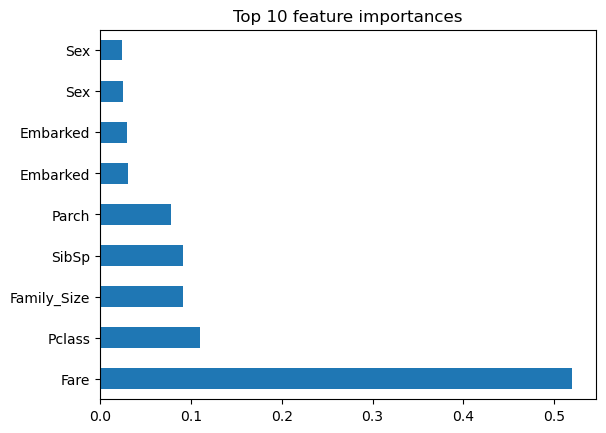

In [196]:

importances=models["RandomForest"].feature_importances_
fi=pd.Series(importances,index=X.columns).sort_values(ascending=False).head(10)
fi.plot(kind='barh')
plt.title("Top 10 feature importances")
plt.show()



Age_Group    G1    G2    G3    G4
Cluster                          
0          0.92  0.08  0.00  0.00
1          0.12  0.55  0.31  0.02
2          0.00  0.65  0.32  0.02
3          0.05  0.76  0.16  0.03
4          0.00  0.47  0.47  0.05
5          0.00  0.20  0.65  0.15
6          0.18  0.77  0.05  0.00
7          0.34  0.31  0.34  0.00
8          0.02  0.33  0.56  0.09
9          0.33  0.33  0.28  0.06
Survived     0     1
Cluster             
0         0.96  0.04
1         0.30  0.70
2         0.88  0.12
3         0.84  0.16
4         0.32  0.68
5         0.65  0.35
6         0.26  0.74
7         0.66  0.34
8         0.04  0.96
9         0.63  0.37
          Age   Fare  Pclass  Family_Size
Cluster                                  
0         4.0   39.7     3.0          7.0
1        27.0   13.0     2.5          2.0
2        29.0    8.0     3.0          1.0
3        29.1    7.8     3.0          1.0
4        35.0  247.5     1.0          2.0
5        44.7   34.8     1.0          1.0
6   

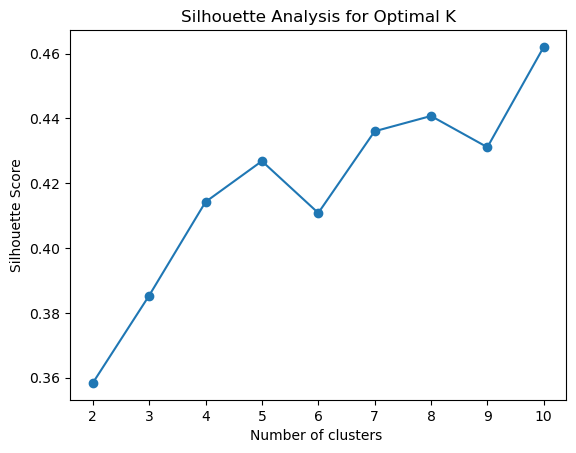

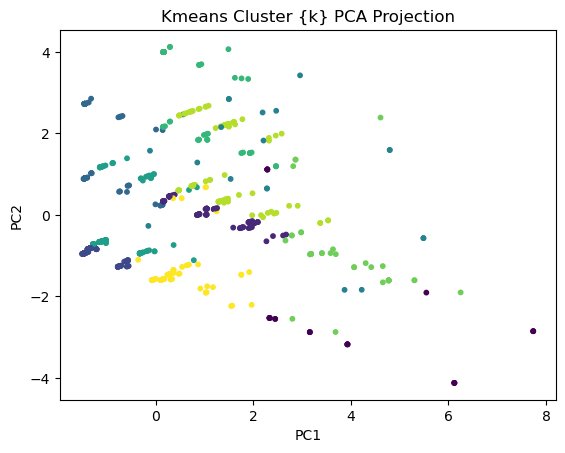

In [184]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
pre=StandardScaler()
Z=pre.fit_transform(X)

best={}
for k in range(2,11):
    kms=KMeans(n_clusters=k,random_state=42,n_init=10).fit_predict(Z)
    sil=silhouette_score(Z,kms)
    best[k]=sil

k=max(best,key=best.get)
kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
titanic_data['Cluster']=kmeans.fit_predict(Z)

print(pd.crosstab(titanic_data['Cluster'],titanic_data['Age_Group'],normalize='index').round(2))
print(pd.crosstab(titanic_data['Cluster'],titanic_data['Survived'],normalize='index').round(2))
print(titanic_data.groupby('Cluster')[['Age','Fare','Pclass','Family_Size']].median().round(1))

plt.plot(list(best.keys()),list(best.values()),marker='o')
plt.title("Silhouette Analysis for Optimal K")
plt.xlabel("Number of clusters ")
plt.ylabel("Silhouette Score")
plt.show()

pca=PCA(n_components=2,random_state=42)
Z2=pca.fit_transform(Z)
plt.scatter(Z2[:,0],Z2[:,1],c=titanic_data['Cluster'],s=10)
plt.title("Kmeans Cluster {k} PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()